# Análisis Exploratorio de Datos: Titanic

En esta actividad usaremos la base de datos de pasajeros del Titanic para practicar **análisis exploratorio de datos (EDA)**.

El objetivo no es hacer la mayor cantidad posible de gráficos, sino aprender a **usar los datos para responder preguntas**.

## Pregunta de investigación

> **¿Qué características de los pasajeros estaban asociadas con la supervivencia en el Titanic?**


## Librerías de visualización
### Matplotlib

Matplotlib tiene dos métodos para crear una figura, uno directo y otro enfocado a objetos. 
Algunos links de interés:

- Argumentos que reciben matplotlib: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html
- Más opciones de gráficos en https://matplotlib.org/2.0.2/gallery.html
- Para una lista de colores disponibles en Matplotlib, https://matplotlib.org/stable/gallery/color/named_colors.html
- Explicación de plt y ax https://towardsdatascience.com/what-are-the-plt-and-ax-in-matplotlib-exactly-d2cf4bf164a9


### Seaborn
Proporciona una interfaz de alto nivel para dibujar gráficos estadísticos atractivos e informativos. A diferencia de Matplotlib, ésta no viene por defecto en Pandas. 
Galería de gráficos: https://seaborn.pydata.org/examples/index.html

Otro link útil para visualizaciones en Python: https://python-graph-gallery.com/


In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_style("white")


## Carga de los datos

Cada fila de la base de datos corresponde a **un pasajero**.

Las principales características disponibles son:

- `Survived`: supervivencia, 0 = no, 1 = sí
- `Pclass`: clase del pasajero, 1 = primera, 2 = segunda, 3 = tercera
- `Sex`: sexo
- `Age`: edad
- `SibSp`: número de hermanos/as o cónyuges a bordo
- `Parch`: número de padres o hijos a bordo
- `Ticket`: identificador del pasaje
- `Fare`: tarifa pagada
- `Cabin`: cabina
- `Embarked`: puerto de embarque, C = Cherbourg, Q = Queenstown, S = Southampton


In [39]:
titanic = pd.read_csv("titanic_semana_02.csv")
titanic.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#### **cuáles variables son numéricas y cuáles son categoricas?**



R:   Las variables **Age, Fare, SibSp, Parch** son numericas.
     Las variables **Passenger, Survived, Pclass, Name, Sex, Ticket, Cabin, Embarked** son variables son categoricas.

# Parte 1: Comprender la muestra

## ¿Quiénes eran los pasajeros del Titanic?

Antes de estudiar la supervivencia, necesitamos comprender a quiénes representan los datos.

Preguntas iniciales:

- ¿Cuántos pasajeros hay?
- ¿Qué características contiene la base de datos?
- ¿Cómo se distribuyen por sexo y clase?
- ¿Qué edades aparecen?
- ¿Cuánto pagaron por sus pasajes?
- ¿Viajaban solos o acompañados?
- ¿Desde qué puerto embarcaron?

Revise la estructura general de la tabla: dimensión, columnas, estadística básica, etc.

In [66]:
print(titanic.shape)
titanic.info()
titanic.describe()

(891, 16)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
 12  Familia      891 non-null    int64  
 13  Persona      891 non-null    str    
 14  Hombres      891 non-null    bool   
 15  Mujeres      891 non-null    bool   
dtypes: bool(2), float64(2), int64(6), str(6)
memory usage: 99.3 KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Familia
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208,1.904602
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429,1.613459
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,1.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400,1.000000
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,1.000000
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000,2.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,11.000000


### Ejemplo de gráfico: pasajeros por sexo

Para una característica categórica podemos comenzar contando cuántos pasajeros pertenecen a cada grupo.


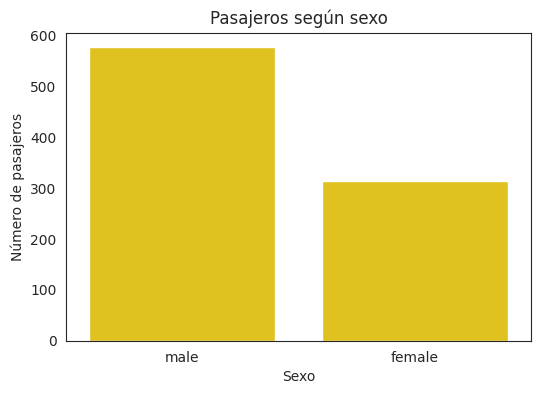

In [41]:
plt.figure(figsize=(6,4))

sns.countplot(data=titanic, x="Sex", color="gold")

plt.xlabel("Sexo")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según sexo")

plt.show()


### Ahora usted

**1. Grafique la cantidad de pasajeros según `Pclass`.**

- Qué clase contiene más pasajeros?
    
    R: La clase que contiene más pasajeros, es la clase 3, la clase 2 y 1 están por debajo pero son parecidas entre sí.
- La muestra está balanceada entre las tres clases?
    
    R: La muestra no es balanceada se nota una clara ya que la cantidad de pasajeros está dominada por la clase 3.


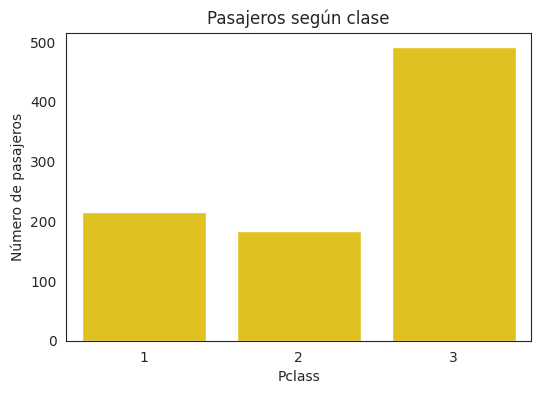

In [42]:
# Escriba aquí su código
plt.figure(figsize=(6,4))

sns.countplot(data=titanic, x="Pclass", color="gold")

plt.xlabel("Pclass")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según clase")

plt.show()


**2. Explore la distribución de `Age` con un histograma.**

Pruebe, por ejemplo, con 15, 30 y 50 bins.

- ¿Qué edades son más frecuentes?
    
    R: Las edades más frencuentes son entre 15 y 30 años
- ¿La distribución parece simétrica?
    
    R: no es simetrica a edades altas no hay valores de cantidad muy altos, y se puede notar un pequeño pico en edades entre 0 y 5 años
- ¿El número de bins cambia su interpretación?
    
    R: De manera general no, pero siendo más especificos entre las edades si. Ya que hay edades especificas que están entre 15 y 30 años que no tienen tanta cantidad de personas por lo que no se deberían considerar valores frecuentes.

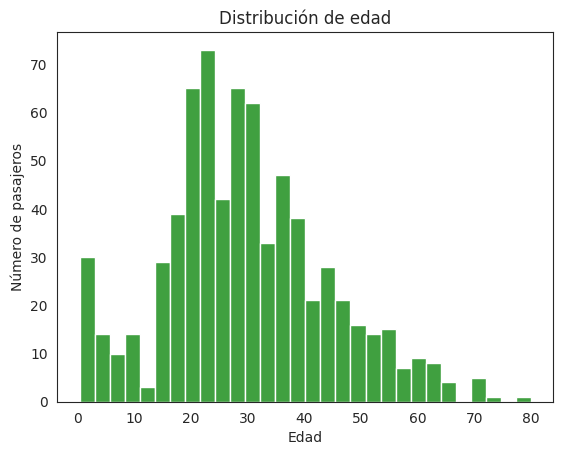

In [43]:
# Escriba aquí su código
# sns.histplot(...)


sns.histplot(data=titanic, x="Age", bins=30, color="g")

plt.xlabel("Edad")
plt.ylabel("Número de pasajeros")
plt.title("Distribución de edad")

plt.show()

**3. Explore la distribución de `Fare`.**

Puede usar un histograma o un boxplot.

- ¿La distribución es simétrica?
    
    R: No es simétrica, se puede notar que la mayoria pagó menos de 50 y que hay valores más altos que 100 y llegando alguno llegando a 500.
- ¿Existen tarifas muy superiores al resto?
    
    R: Si. Hay valores por encima del limite superior del boxplot.
- ¿Qué podría significar esto?
    
    R: No son necesariamente errore, puede ser un dato que visualice la gran diferencia que hay entre clases


<function matplotlib.pyplot.show(close=None, block=None)>

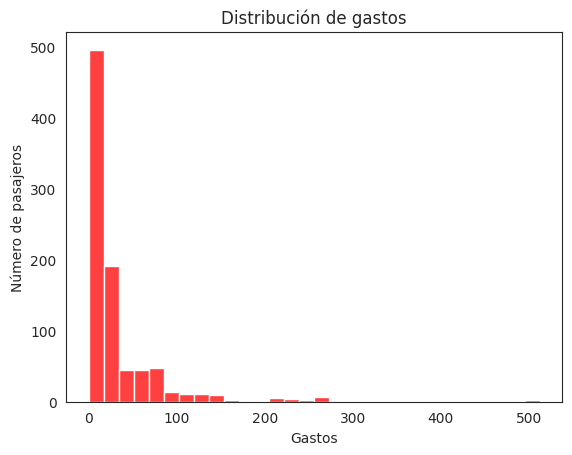

In [44]:
# Escriba aquí su código

sns.histplot(data=titanic, x="Fare", bins=30, color="r")

plt.xlabel("Gastos")
plt.ylabel("Número de pasajeros")
plt.title("Distribución de gastos")

plt.show


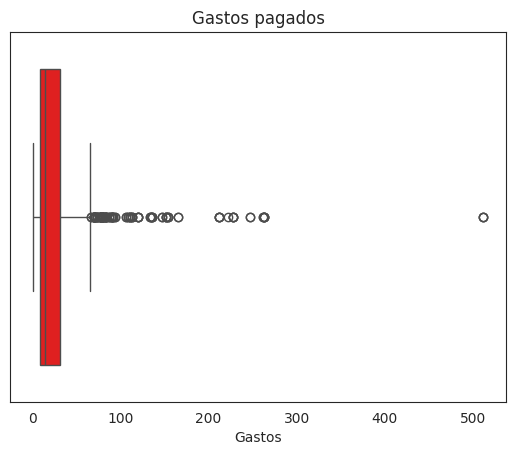

In [45]:
sns.boxplot(data=titanic, x="Fare", color="r")


plt.xlabel("Gastos")
plt.title("Gastos pagados")
plt.show()

# Parte 2: Calidad de los datos

## ¿Qué información falta y por qué podría importar?

Antes de interpretar cualquier patrón debemos revisar la calidad de los datos.

Nos interesa detectar:

- valores faltantes
- características con mucha información incompleta
- valores extremos o sospechosos
- decisiones de limpieza que puedan cambiar nuestras conclusiones


In [46]:
datos_faltantes = titanic.isnull().sum()
datos_faltantes


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Ejemplo de gráfico: valores faltantes

Podemos visualizar cuántos datos faltan en cada característica.


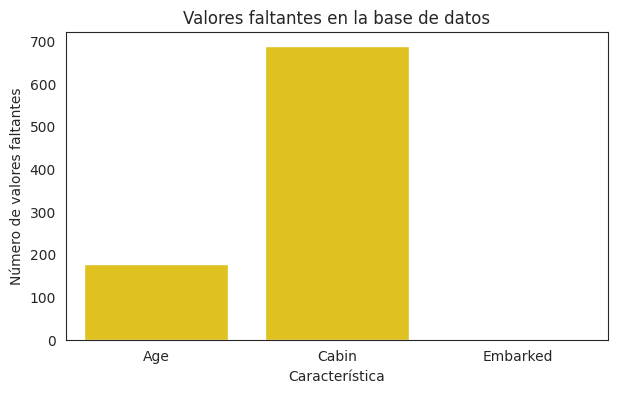

In [47]:
faltantes = datos_faltantes[datos_faltantes > 0]

plt.figure(figsize=(7,4))

sns.barplot(x=faltantes.index, y=faltantes.values, color='gold')

plt.xlabel("Característica")
plt.ylabel("Número de valores faltantes")
plt.title("Valores faltantes en la base de datos")

plt.show()


### Ahora usted

Observe especialmente `Age`, `Cabin` y `Embarked`.

**1. Compare la media y la mediana de `Age`.**

- Son similares?
    
    R: son parecidos pero no son iguales la mediana (28.0) es un poco menor que la media (~29.7) 
- Es la media una buena representación de una edad típica?
    
    R: La diferencia no es tan grande por lo que la media es una buena presentación para este caso. De todas maneras esto es solo para las edades que se conocen por lo que si se conocieran todos los datos de la muestra, la edad típica podría variar.


In [48]:
# Escriba aquí su código

media_Age = titanic["Age"].mean()   
mediana_Age = titanic["Age"].median()

print("media:", media_Age)
print("mediana:", mediana_Age)

std = titanic["Age"].std()
std_mean = titanic["Age"].fillna(titanic["Age"].mean()).std()
print("Desviación estandar:", std )
print("Desviación estandar considerando los valores Nan como la media: ", std_mean)


media: 29.69911764705882
mediana: 28.0
Desviación estandar: 14.526497332334042
Desviación estandar considerando los valores Nan como la media:  13.002015226002882


**2. La edad tiene datos faltantes.**

- Le parece razonable reemplazar todas las edades faltantes por la media?
    
    R: No me parece razonable ya que los datos faltantes de edad son 177, asi que se podría cometer el error de inventar la edad de alguna de las personas dentro de esa cantidad.
- Qué problema podría producir esa decisión en la distribución de edades?
    
    R: Podría generar un pico artificial en 29.7 años, lo que cambiaría la forma del histograma, y cambiarían datos como la dispersión.
- Qué otra estrategia consideraría?
    
    R: Consideraría usar una columna "nan_Age" para verificar si estos se comportan de una manera distinta.


**3. `Cabin` tiene una gran cantidad de valores faltantes.**

- Intentaría rellenarlos?
    
    R: No ya que hay muchisimos datos faltantes y el valor que tiene esta variable es un codigo complejo. Por lo que no existe con que rellenarlo sino se estarían inventando datos.
- Eliminaría la característica?
    
    R: No necesariamente porque las pocas que se registraron pueden ser utiles.
- Podría el hecho de conocer o no la cabina contener información por sí mismo?
    
    R: Si podría ser que haya una relación con que se conozca la cabina con alguna otra variable, como por ejemplo la clase.

    
No hay una única respuesta correcta: justifique su decisión.


**4. `Embarked` tiene pocos datos faltantes.**

- Qué estrategia simple usaría en este caso?

    R: Aqui si se podría reemplazar por ejemplo con la moda ya que solo son 2 datos los que faltan. No haría una gran diferencia rellenar los datos.
- Por qué el tratamiento puede ser distinto al de `Cabin`?

    R: Puede ser distinto a "Cabin" ya que la diferencia recae en la cantidad de datos que faltan. Aqui simplemente faltan 2 datos comparados a 687 que faltan de "Cabin". Claramente los cambios que se hagan en esos 687 como reemplazarlos por la media generaría cambios importantes en los datos y generaría valores inventados.


# Parte 3: Explorar relaciones entre características3

## ¿Cómo se relacionan las características de los pasajeros?

Después de estudiar las características individualmente, podemos comenzar a buscar estructura en los datos.

Preguntas posibles:

- La tarifa pagada está relacionada con la clase?
- Las edades son similares en todas las clases?
- Quiénes viajaban acompañados?
- Hay características que contienen información parcialmente similar?



### Ejemplo de gráfico: tarifa según clase

Un boxplot permite comparar la distribución de una característica numérica entre distintos grupos.


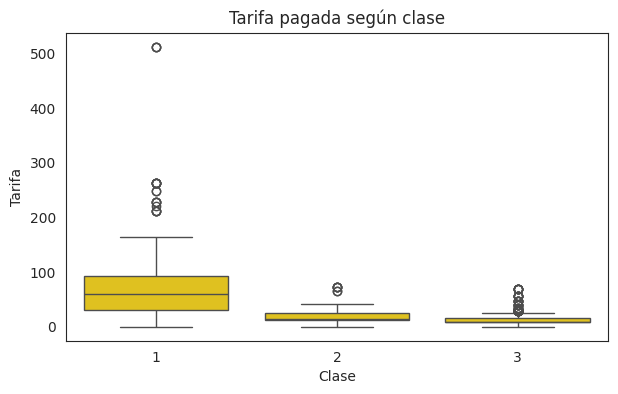

In [49]:
plt.figure(figsize=(7,4))

sns.boxplot(data=titanic, x="Pclass", y="Fare", color='gold')

plt.xlabel("Clase")
plt.ylabel("Tarifa")
plt.title("Tarifa pagada según clase")

plt.show()


### Preguntas

- La tarifa parece estar relacionada con la clase?
- Hay dispersión dentro de cada clase?
- Existen valores extremos?
- Diría que `Fare` y `Pclass` contienen exactamente la misma información?


### Ahora usted

**1. Compare la distribución de edad entre las tres clases.**

Use un gráfico que permita comparar las distribuciones.

- Los pasajeros tienen edades similares en todas las clases?

    R: No se puede notar una tendencia importante, la mediana de edad baja al bajar de clase.
- Qué diferencias observa?

    R: La primra clase es la que tiene más dispersión y donde la está la mayoría de adultos mayores y la tercera clase es la que concentra a la parte más joven de la muestra.


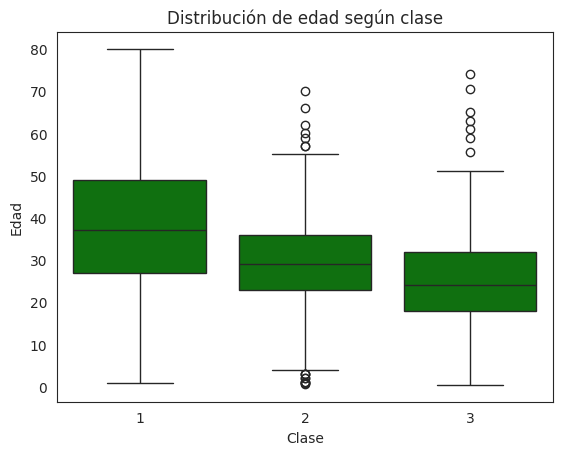

In [50]:
# Escriba aquí su código
# sns.boxplot(...)
sns.boxplot(data=titanic, x="Pclass", y="Age", color="g")

plt.xlabel("Clase")
plt.ylabel("Edad")
plt.title("Distribución de edad según clase")

plt.show()

**2. Las características `SibSp` y `Parch` contienen información sobre familiares a bordo.**

Construya una nueva característica llamada `Familia`, que represente el número total de personas del grupo familiar incluyendo al propio pasajero:

\[
Familia = SibSp + Parch + 1
\]


In [51]:
# Complete el código

titanic["Familia"] = titanic["SibSp"] + titanic["Parch"] + 1



**3. Explore la nueva característica `Familia`.**

- La mayoría de los pasajeros viajaba sola o acompañada?
    
    R: La mayoría viajaba sola, siendo un poco más de 500 personas que iban solas a bordo.
- Hay grupos familiares muy grandes?

    R: Si, hay grupos muy grandes habiendo casos de 6,7,8 y 11 personas. Pero eran unos pocos grupos.
- Cambiaría su interpretación si solo mirara `SibSp` o `Parch` por separado?

    R: Si ya que una persona que por ejemplo tenía SibSp = 0 no viajaba necesariamente solo porque podía haber ido con sus papás o hijos (Parch > 0). Si solo se mirara una columna se estaría estimando mal la cantidad de personas que viajan solas, aumentando esta cantidad. 


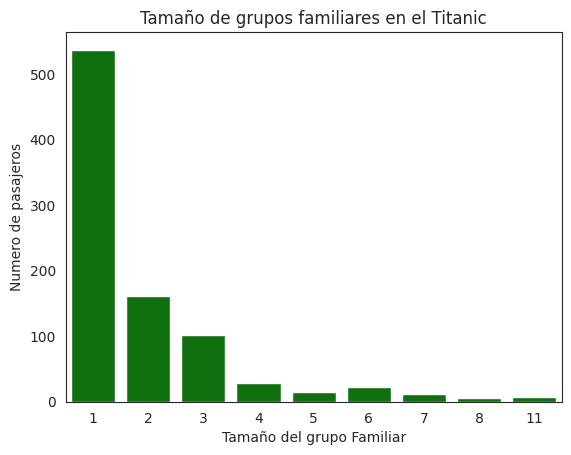

In [52]:
# Escriba aquí su código
sns.countplot(data=titanic, x="Familia", color= "g")

plt.xlabel("Tamaño del grupo Familiar")
plt.ylabel("Numero de pasajeros")
plt.title("Tamaño de grupos familiares en el Titanic")
plt.show()

# Parte 4: Investigar la supervivencia

## ¿Qué características estaban asociadas con la supervivencia?

Ahora incorporaremos `Survived`, la variable que queremos comprender.

Investigaremos si la supervivencia está asociada con características como:

- sexo
- clase
- edad
- tamaño del grupo familiar


### Ejemplo de gráfico: supervivencia según sexo

Como `Survived` toma valores 0 y 1, su promedio dentro de un grupo corresponde a la **fracción de pasajeros que sobrevivió**.

`seaborn.barplot` calcula por defecto la media de la variable del eje vertical.


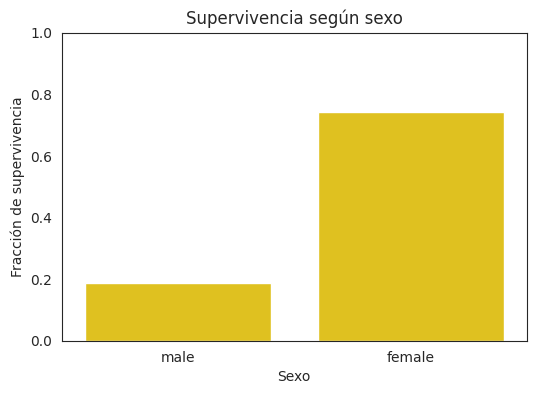

In [53]:
plt.figure(figsize=(6,4))

sns.barplot(data=titanic, x="Sex", y="Survived", errorbar=None, color='gold')

plt.xlabel("Sexo")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según sexo")
plt.ylim(0,1)

plt.show()


### Preguntas

- La fracción de supervivencia es similar para hombres y mujeres?

    R: No, se nota una clara diferencia en la que las mujeres es la fracción que más sobrevivió.
- Podemos concluir a partir de este gráfico por qué existe la diferencia?

    R: No se puede concluir nada sobre por qué existe esta diferencia. El grafico muestra que existe esta diferencia pero no la explica. Se necesitaría relacionarla a otras variables para poder conseguir una conclusión.

### Ahora usted

**1. Explore la supervivencia según `Pclass`.**

- Hay diferencias entre las tres clases?

    R: Si, hay una clara diferencia, donde se puede notar una mayoría de fracción de supervivencia en la clase 1 teniendo un poco más del 60%. Tambien podemos ver que cerca del 50% de la clase 2 tambien sobrevivió y por ultimo podemos notar que hay una minoría de fracción de supervivencia en la clase 3 teniendo un valor cerca al 25%.
- Existe una tendencia?

    R: Se puede notar una tendencia monónotona decreciente hacia clases inferiores. A menor clase menor supervivencia.


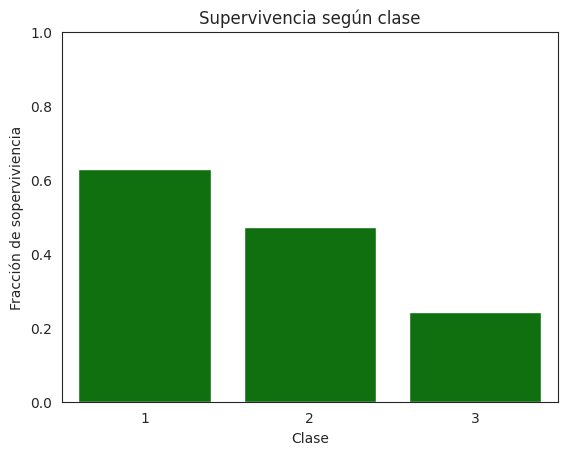

In [ ]:
# Escriba aquí su código

sns.barplot(data=titanic, x="Pclass", y="Survived",errorbar=None, color="g")

plt.xlabel("Clase")
plt.ylabel("Fracción de soperviviencia")
plt.title("Supervivencia según clase")
plt.ylim(0,1)

plt.show()

**2. Explore la supervivencia según edad.**

Puede comparar las distribuciones de edad de quienes sobrevivieron y quienes no sobrevivieron.

- La edad parece estar asociada con supervivencia?

    R: No se nota una relación muy llamativa, la edad no separa a los sobrevivientes de los no sobrevivientes.
- Hay algún grupo de edad que llame particularmente su atención?

    R: Si, serían las edades menores a 10 años, esta población es la unica que sobrevivieron más de los que murieron.


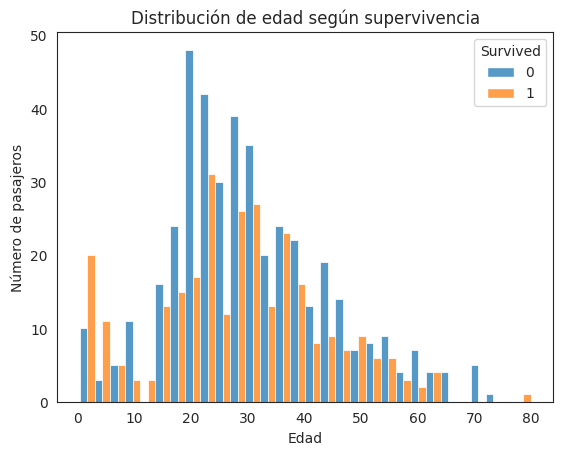

In [55]:
# Escriba aquí su código
sns.histplot(data=titanic, x="Age", hue="Survived", bins=30, multiple="dodge")

plt.xlabel("Edad")
plt.ylabel("Número de pasajeros")
plt.title("Distribución de edad según supervivencia")

plt.show()

**3. Explore la supervivencia según `Familia`.**

- Viajar solo parece favorable o desfavorable?

    R: Viajar solo parece desfavorable, la fracción de supervivencia de las personas que viajaron solas fue del 30%. por debajo de los otros tamaños.
- La relación parece simple?

    R: No, no es una relación monotna. Se puede notar valores maximos entre 2 y 4 personas y despues cae.
- Qué ocurre con los grupos familiares grandes?

    R: En los grupos familiares grandes desde 5 o más personas la supervivencia baja mucho, y en las de 8 y 11 personas la supervivencia es 0.


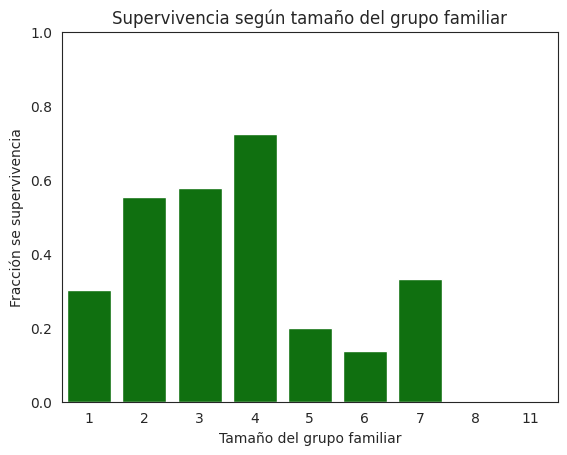

In [56]:
# Escriba aquí su código

sns.barplot(data=titanic, x="Familia", y="Survived", errorbar=None, color="g")

plt.xlabel("Tamaño del grupo familiar")
plt.ylabel("Fracción se supervivencia")
plt.title("Supervivencia según tamaño del grupo familiar")
plt.ylim(0,1)

plt.show()

# Parte 5: Agregar contexto

## ¿Cambia una relación cuando consideramos otra característica?

Una relación global puede esconder comportamientos diferentes dentro de la muestra.

Ya estudiamos por separado:

- `Pclass` y supervivencia
- `Sex` y supervivencia

Ahora podemos preguntar:
 **¿La relación entre clase y supervivencia es igual para hombres y mujeres?**

Esta es una forma sencilla de análisis multivariado: consideramos varias características al mismo tiempo.


### Ejemplo de gráfico: clase, sexo y supervivencia


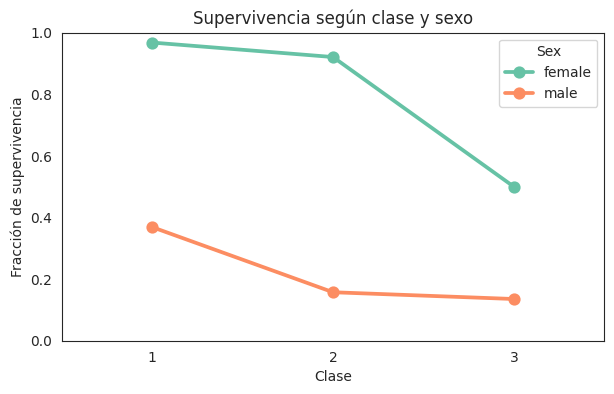

In [57]:
plt.figure(figsize=(7,4))

sns.pointplot(data=titanic,
              x="Pclass",
              y="Survived",
              hue="Sex",
              palette="Set2",
              errorbar=None)

plt.xlabel("Clase")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según clase y sexo")
plt.ylim(0,1)

plt.show()


### Preguntas sobre el ejemplo

- La relación entre clase y supervivencia es igual para hombres y mujeres?

    R: No, en ambos sexos la supervivencia baja al bajar de clase, pero las magnitudes son muy distintas, por ejemplo, las mujeres que sobreviven de las clases 1 y 2 son más del 90% en comparación de los hombres de las clases 1 y 2 que hay una fracción de supervivencia de 40% y 20%, respectivamente.
- Qué información se perdía cuando mirábamos solamente `Pclass`?

    R: Se perdía que la diferencia entre las clases se debía en gran parte al sexo. Y también se perdía la información de que casi todas las mujeres de las clases 1 y 2 se salvaron, en cambio, la mayoría de los hombres no.
- Qué información se perdía cuando mirábamos solamente `Sex`?

    R: Que el ~70% de supervivencia de mujeres esconde que una mujer en clase 1 estaba casi asegurada mientras que una de clase 3 tenía apenas la mitad de posibilidades.
- Hay algún grupo particularmente favorecido o desfavorecido?

    R: Los grupos más favorecidos fueron las mujeres de clase 1 y 2, ambas arriba del 90%. Y los grupos más desfavorecidos fueron hombres de clase 2 y 3, ambos por debajo del 20%.



### Ahora usted

**1. Cree una característica `Persona` con tres categorías:**

- `mujer`
- `hombre`
- `niño/a`

Considere como niño/a a un pasajero menor de 16 años.


In [58]:
# Complete el código

def clasificar(fila):
    if fila["Age"] < 16:
        return "niño/a"
    else:
        return fila["Sex"]


titanic["Persona"] = titanic.apply(clasificar, axis=1)

# Revise el resultado
titanic["Persona"].value_counts()


Persona
male      537
female    271
niño/a     83
Name: count, dtype: int64

**2. Explore la supervivencia según `Persona` y `Pclass`.**

- Los niños presentan el mismo patrón que los adultos?

    R: Los niños no siguen el mismo patrón de los adultos no hay un patrón monótono en los datos. Se puede ver una subida desde la clase 1 hacia la clase 2 y un decaimiento muy brusco desde la clase 2 hasta la 3. Contrariamente al decaimiento casi monotono de los adultos.
- La clase sigue siendo importante dentro de cada grupo?

    R: La clase sigue siendo importante en cada grupo. Sobre todo en los niños se puede ver una discriminación bien brusca sobre todo con la clase 3.
- Qué combinación de características parece asociarse con la mayor supervivencia?

    R: La mejor combinación parece ser niño o mujer en clase 1 o 2 para mayor supervivencia.


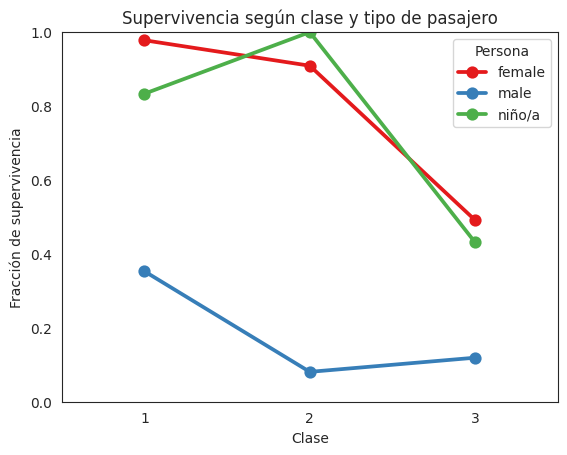

In [59]:
# Escriba aquí su código

sns.pointplot(data=titanic,
              x="Pclass",
              y="Survived",
              hue="Persona",
              palette="Set1",
              errorbar=None)

plt.xlabel("Clase")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según clase y tipo de pasajero")
plt.ylim(0,1)

plt.show()


**3. Elija una relación adicional para explorar incorporando una tercera característica.**

Algunas ideas:

- edad + sexo + supervivencia;
- tamaño de familia + clase + supervivencia;
- puerto de embarque + clase + supervivencia.

No necesita crear una figura complicada. El objetivo es responder una pregunta concreta.

**Escriba primero la pregunta que quiere investigar y luego construya el gráfico.**


En total hay 577 hombres y 314 mujeres. En total hay 891 pasajeros


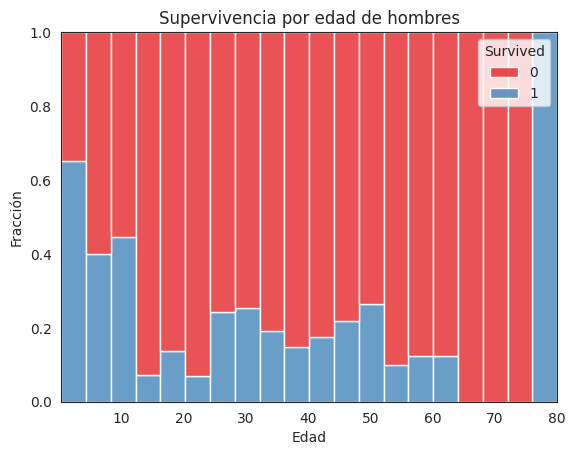

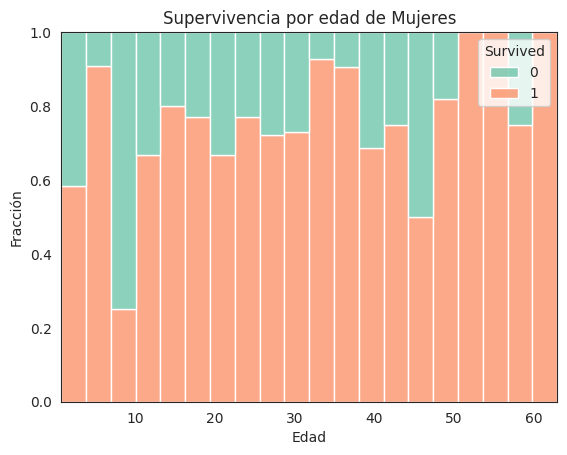

In [ ]:
# Pregunta: ¿la ventaja de supervivencia por edad es igual en hombre y mujeres?

# Código:



titanic["Hombres"] = titanic["Sex"] == "male"
titanic["Mujeres"] = titanic["Sex"] == "female"

total_hombres = titanic["Hombres"].sum()
total_mujeres = titanic["Mujeres"].sum()
total_pasajeros = total_mujeres + total_hombres

print("En total hay", total_hombres, "hombres y", total_mujeres, "mujeres. En total hay", total_pasajeros, "pasajeros" )

sns.histplot(data=titanic[titanic["Hombres"]], x="Age", hue="Survived",bins=20, palette="Set1", multiple="fill") #con multiple podemos normalizar y conseguir fracciones de población

plt.xlabel("Edad")
plt.ylabel("Fracción")
plt.title("Supervivencia por edad de hombres")
plt.show()


sns.histplot(data=titanic[titanic["Mujeres"]], x="Age", hue="Survived", bins=20, palette="Set2", multiple="fill")


plt.xlabel("Edad")
plt.ylabel("Fracción")
plt.title("Supervivencia por edad de Mujeres")

plt.show()




- En hombres se puede notar una diferencia entre las edades. Los menores de 15 años tienen mayor fracción de supervivencia que los adultos sin considerar ese valor extremo en 80 que puede ser considerado por la poca cantidad de personas de gran edad.

- En mujeres la fracción en general es alta y es bien uniforme en todas las edades. Ser joven no aporta mucho como en hombres porque las mujeres ya sobrevivian en alta proporción de cualquier forma.

- Interpreto que la ventaja de supervivencia por edad funciona solo para los hombres en el caso del titanic.

# Parte 6: Conclusión

## ¿Qué podemos concluir?

El EDA no termina cuando encontramos diferencias entre grupos.

Queremos distinguir entre:

### Observación
Algo que vemos directamente en los datos.

### Interpretación
Cómo describimos ese patrón.

### Hipótesis
Una explicación posible que debería ser evaluada con más información.

Por ejemplo:

> **Observación:** las mujeres presentan una mayor fracción de supervivencia que los hombres.

- **Podemos concluir, solo a partir de esta base de datos, que durante la evacuación se dio prioridad a mujeres y niños?**
- **Qué información adicional necesitaríamos para evaluar esa hipótesis?**
- **Qué otras explicaciones podrían producir el mismo patrón de supervivencia?**

## Síntesis del análisis

Revise todas las figuras construidas y responda:

### 1. Quiénes eran los pasajeros del Titanic?

Describa brevemente la muestra considerando, al menos:

- sexo
- clase
- edad
- tamaño de familia.

R: La muestra contiene 891 pasajeros y hay más hombres que mujeres casi duplicando su cantidad. La la clase 3 concentra más pasajeros que las clases 1 y 2 que tienen cantidades similares de personas. Las edades se agrupan mayoritariamente entre los 20 y 40 años teniendo una mediana de 28 años, con una baja en la cantidad de pasajeros hacia edades altas. Respecto al tamaño familiar, la mayoría de pasajeros viajaban solos y las personas con más de cuatro personas son poco frecuentes.


### 2. Qué características estaban asociadas con la supervivencia?

Considere:

- sexo
- clase
- edad
- viajar solo o acompañado.


R:  El sexo es una de las caracteristicas mejor asociadas con la supervivencia, la fracción de supervivencia de las mujeres es mucho mayor que la de los hombres. La clase muestra una tendencia respecto a la supervivencia, con esta disminuyendo de clase 1 a clase 3. Respecto a la edad, no hay una asociación evidente con la supervivencia, salvo en los menores de 10 años donde se pudo notar que era la unica edad donde había mas supervivientes que fallecidos. Viajar solo era desfavorable versus viajar en un grupo familiar pequeño (de 2 a 4 personas), ya que los grupos numerosos también mostraban una baja en la supervivencia.



### 3. Qué relaciones cambiaron al considerar varias características al mismo tiempo?

Use como ejemplo al menos uno de los análisis multivariados realizados.

Por ejemplo la edad. Al compararla con los sobrevivientes con los no sobrevivientes esta variable no parecía muy relevante. Pero al separar por sexo se pudo notar que la ventaja que existía por se niño existe solo en los hombres, las mujeres tienen una supervivencia alta en todo el rango de edades, asi que ser joven no aportaba como si aporta en hombres.  


### 4. Encontró características que contienen información relacionada?

Explique al menos un caso.

Si, SibSp y Parch describen una caracteristica muy parecida pero desde una perspectiva distinta, por lo que al considerar solo una se podía sobreestimar la cantidad de pasajeros que viajaban solos, por esta razón se combinaron estas caracteristicas en Familia.

### 5. Qué resultado le pareció más inesperado?

Proponga una posible explicación, dejando claro qué parte corresponde a una observación y qué parte corresponde a una hipótesis.

Observación: los pasajeros que viajaban solos tienen una fracción de supervivencia menor que los que iban en grupos familiares pequeños. Yo esperaba lo contrario, ya que moverse solo debería ser más rapido en una evacuacion que con personas. 

Hipótesis: los grupos pequeños pudieron ayudarse de alguna manera a llegar a cubierta más rapido o recibieron algún tipo de prioridad. 

# Conclusión final

## ¿Cuál es el perfil del pasajero típico que sobrevivió?

A partir de **sus propios resultados**, escriba una conclusión breve que caracterice al pasajero con mayor probabilidad de haber sobrevivido en esta muestra.

Considere, cuando corresponda:

- sexo
- edad
- clase
- tamaño del grupo familiar
- otras características que hayan resultado relevantes

Su respuesta debe estar respaldada por las figuras que construyó.


### Escriba aquí su conclusión

**El pasajero típico que sobrevivió...**

*(Complete con un párrafo breve basado en su análisis.)*

El pasajero con mayor probablididad de supervivencia en este caso es una mujer o un niño de clase 1 o 2, viajando con un grupo familiar pequeño. El sexo es la caracteristica que más diferencia a un sobreviviente de un no sobreviviente, la clase ayuda a englobar a las personas con más probabilidades de supervencia ya que en cualquier sexo tiene la misma tendencia monótona decreciente que decrece de clase 1 a 3. La edad importa sobre todo en la infancia de hombres donde se puede notar una ventaja en la supervivencia. Y por ultimo, viajar acompañado resultó en ser más ventajoso que viajar solo. 